In [42]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits

import healpy as hp

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../../notebooks/matplotlibrc')

In [15]:
sys.path.append('../..')
from utils.data_processing import get_GC_data

In [19]:
DDIR = '/data/submit/yitians/fermi/templates/CZMS_exposed/573weeks_ultracleanveto_bestpsf'

In [3]:
tmpl_codes = ['bs', '0w', '5q', '9l', '9z', 'bh', 'ba', '22', '23', 'ch',
              '24', '26', '2c', '2e', 'c4', '2g', '2i', '2p', '2q', '2r',
              '2s', '2t', '2u', '2v', '2w', '2y', '2z', '30', '31', '32',
              '3j', '3z', '5s', '67', '6e', '6n', '6z', '70', '71', '7c',
              '7n', '7o', '7p', '7t', '7u', '80', '8f', '8l', '8t', '93',
              'au', 'ay', 'bf', 'cg', 'cv', 'd1', 'dy', '0a', '0b', '0c',
              '0g', '0t', '0u', '0v', '14', '1c', '1d', '1e', '1i', '1j',
              '1k', '1nB', '1oB', '1pB', '1qB', '1rB', '1sB', '1xB', '1yB', '1zB']
tmpl_types = ['pi0', 'bremss', 'ICS']

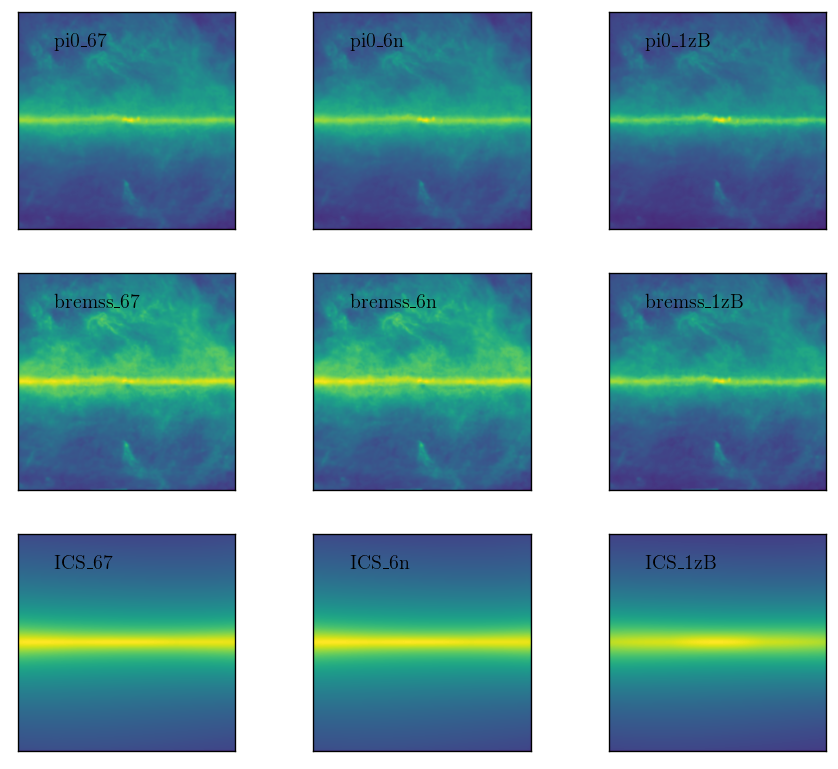

In [11]:
plot_codes = ['67', '6n', '1zB']

fig, axs = plt.subplots(3, len(plot_codes), figsize=(3*len(plot_codes), 8))
for i, c in enumerate(plot_codes):
    for j, t in enumerate(tmpl_types):
        with fits.open(f'{DDIR}/{t}_{c}.fits') as hdul:
            z = hdul[0].data[10]
            axs[j,i].imshow(np.flip(np.log10(z)))
            axs[j,i].text(100, 100, f'{t}_{c}', fontsize=12)
            axs[j,i].set(xticks=[], yticks=[])

## does gtsrcmaps apply exposure

In [71]:
hdul_in = fits.open('tmp/bremss_0c_in.fits')
hdul_exp = fits.open('/data/submit/yitians/fermi/fermidata/exposure/pass8_573weeks/exposure-edge-ultracleanveto-bestpsf.fits')
hdul_out = fits.open(f'{DDIR}/bremss_0c.fits')

In [72]:
exp = get_GC_data(hdul_exp[0], 30, verbose=True)

get_GC_data: l: [1500:2100]
get_GC_data: b: [600:1200]


In [75]:
hdul_p6_out = fits.open('/data/submit/yitians/fermi/templates/p6v11_ultracleanveto_bestpsf_irfsv3_halfsky1.fits')
z_p6_out = hdul_p6_out[3].data[10, 600:1200, 600:1200]
hdul_p6_in = fits.open('/data/submit/yitians/fermi/templates/gll_iem_v02_P6_V11_DIFFUSE.fit')
z_p6_in = get_GC_data(hdul_p6_in[0], 30, verbose=True)[10]

get_GC_data: l: [300:420]
get_GC_data: b: [120:240]


In [92]:
hdul_exp[2].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional binary table                     
NAXIS1  =                   16 / width of table in bytes                        
NAXIS2  =                60291 / number of rows in table                        
PCOUNT  =                    0 / size of special data area                      
GCOUNT  =                    1 / one data group (required keyword)              
TFIELDS =                    2 / number of fields in each row                   
TTYPE1  = 'START   '           / label for field   1                            
TFORM1  = 'D       '           / data format of field: 8-byte DOUBLE            
TUNIT1  = 's       '           / physical unit of field                         
TTYPE2  = 'STOP    '           / label for field   2                            
TFORM2  = 'D       '        

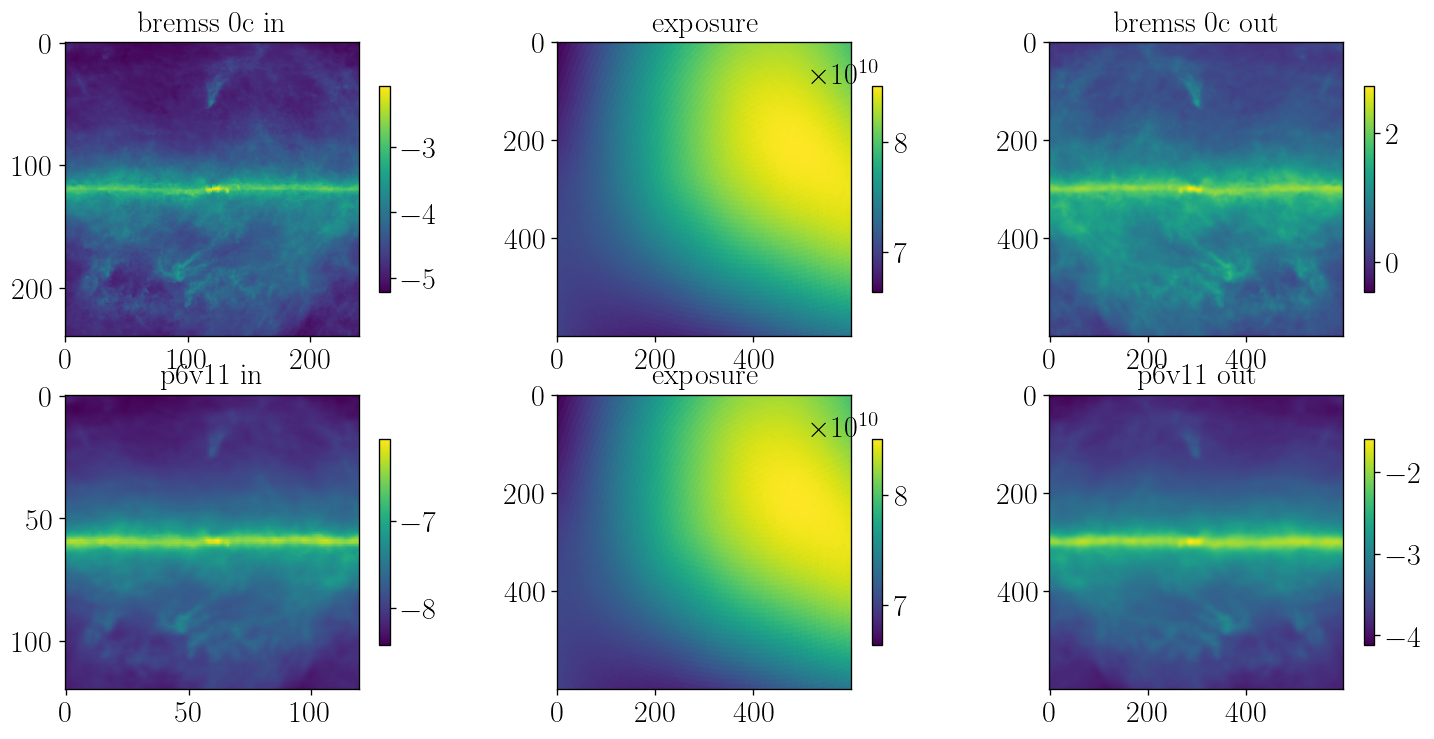

In [84]:
fig, axs = plt.subplots(2, 3, figsize=(15,7))
im0 = axs[0,0].imshow((np.log10(hdul_in[0].data[10])))
im1 = axs[0,1].imshow(exp[5])
im2 = axs[0,2].imshow((np.log10(hdul_out[0].data[10])))
axs[0,0].set(title='bremss 0c in')
axs[0,1].set(title='exposure')
axs[0,2].set(title='bremss 0c out')
fig.colorbar(im0, ax=axs[0,0], shrink=0.7)
fig.colorbar(im1, ax=axs[0,1], shrink=0.7)
fig.colorbar(im2, ax=axs[0,2], shrink=0.7)

im0 = axs[1,0].imshow((np.log10(z_p6_in)))
im1 = axs[1,1].imshow(exp[5])
im2 = axs[1,2].imshow((np.log10(z_p6_out)))
axs[1,0].set(title='p6v11 in')
axs[1,1].set(title='exposure')
axs[1,2].set(title='p6v11 out')
fig.colorbar(im0, ax=axs[1,0], shrink=0.7)
fig.colorbar(im1, ax=axs[1,1], shrink=0.7)
fig.colorbar(im2, ax=axs[1,2], shrink=0.7);